In [1]:
!pip install tensorflow numpy pandas scikit-learn matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, GRU, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:
# Load dataset (update path if necessary)
file_path = "/content/Combined_AQ_Weather_NO2_AQI_2024_Robust.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns
df = df.drop(columns=["Datetime", "City", "AQI_Category"])

# Handle missing values (median fill)
df.fillna(df.median(numeric_only=True), inplace=True)

# Scale features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# Display dataset info
print("Scaled dataset shape:", scaled_df.shape)
scaled_df.head()


Scaled dataset shape: (26445, 14)


,PM2.5,PM10,NO,CO,Ozone,temperature_2m,relative_humidity_2m,precipitation,rain,pressure_msl,windspeed_10m,winddirection_10m,NO2,Final_AQI
0,0.124192,0.191329,0.027280,0.044532,0.043229,0.086758,1.000000,0.0,0.0,0.827586,0.102902,0.844011,0.021750,0.582517
1,0.106026,0.168907,0.029428,0.044118,0.036185,0.164384,0.905263,0.0,0.0,0.859195,0.087071,0.983287,0.023032,0.465293
2,0.125578,0.198320,0.030822,0.044532,0.041597,0.173516,0.894737,0.0,0.0,0.870690,0.094987,1.000000,0.024101,0.591518
3,0.106238,0.182708,0.036739,0.044532,0.034489,0.191781,0.863158,0.0,0.0,0.887931,0.142480,0.008357,0.029228,0.466693
4,0.107676,0.199430,0.050242,0.044739,0.036915,0.205479,0.821053,0.0,0.0,0.905172,0.160950,0.005571,0.038287,0.475895


In [4]:
def create_sequences(data, target_col, time_steps=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    for i in range(time_steps, len(data)):
        X.append(data.iloc[i-time_steps:i].values)
        y.append(data.iloc[i, target_idx])
    return np.array(X), np.array(y)

# Create input sequences and labels
X, y = create_sequences(scaled_df, target_col="Final_AQI", time_steps=24)

# Chronological 80/20 split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (21136, 24, 14)
Testing shape: (5285, 24, 14)


In [5]:
def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=False, input_shape=input_shape),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model


In [8]:
def train_and_evaluate(model_fn, X_train, y_train, X_test, y_test, name, epochs=40, batch_size=32):
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = model_fn(input_shape)
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, verbose=1)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name} -> RMSE: {rmse:.3f}, R²: {r2:.3f}")
    return model, preds, history


In [9]:
cnn_lstm_model, pred_cnnlstm, hist_cnnlstm = train_and_evaluate(build_cnn_lstm, X_train, y_train, X_test, y_test, "CNN-LSTM")
bilstm_model, pred_bilstm, hist_bilstm = train_and_evaluate(build_bilstm, X_train, y_train, X_test, y_test, "BiLSTM")
gru_model, pred_gru, hist_gru = train_and_evaluate(build_gru, X_train, y_train, X_test, y_test, "GRU")


Epoch 1/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0217 - val_loss: 0.0032
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0082 - val_loss: 0.0030
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0081 - val_loss: 0.0032
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0074 - val_loss: 0.0030
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0070 - val_loss: 0.0029
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0069 - val_loss: 0.0032
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0067 - val_loss: 0.0027
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0065 - val_loss: 0.0029
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0066 - val_loss: 0.0029
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0067 - val_loss: 0.0028
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


661/661 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0165 - val_loss: 0.0030
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0080 - val_loss: 0.0027
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0074 - val_loss: 0.0028
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0074 - val_loss: 0.0031
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0068 - val_loss: 0.0025
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0065 - val_loss: 0.0025
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0067 - val_loss: 0.0025
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0066 - val_loss: 0.0026
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0067 - val_loss: 0.0025
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0066 - val_loss: 0.0027
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0140 - val_loss: 0.0026
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0080 - val_loss: 0.0027
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0070 - val_loss: 0.0025
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0076 - val_loss: 0.0027
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0069 - val_loss: 0.0027
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0066 - val_loss: 0.0025
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0064 - val_loss: 0.0026
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0067 - val_loss: 0.0025
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0062 - val_loss: 0.0025
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.

In [11]:
ensemble_pred = np.mean(np.column_stack((pred_cnnlstm, pred_bilstm, pred_gru)), axis=1)

rmse_ensemble = np.sqrt(mean_squared_error(y_test, ensemble_pred))
r2_ensemble = r2_score(y_test, ensemble_pred)

print(f"Ensemble (Average) -> RMSE: {rmse_ensemble:.3f}, R²: {r2_ensemble:.3f}")


Ensemble (Average) -> RMSE: 0.050, R²: 0.811


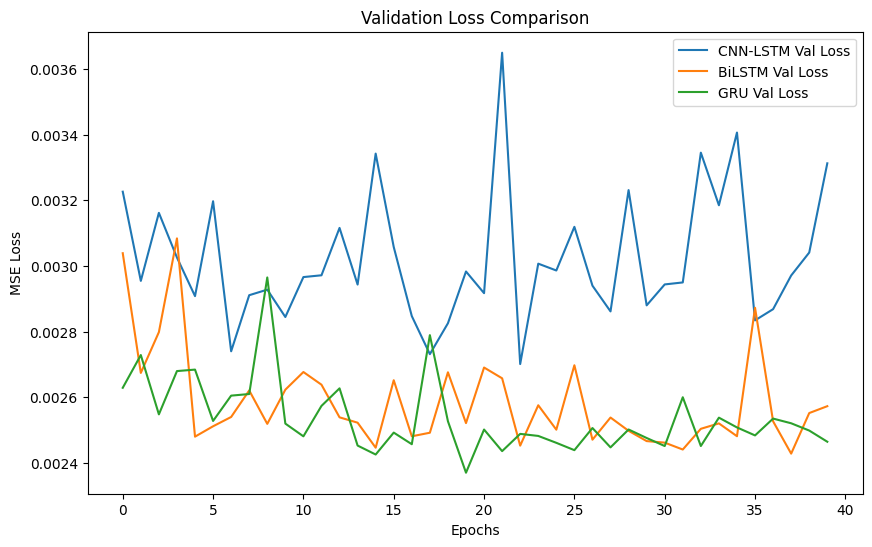

In [13]:
def plot_training_curves(histories, names):
    plt.figure(figsize=(10,6))
    for h, n in zip(histories, names):
        plt.plot(h.history['val_loss'], label=f'{n} Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()

plot_training_curves([hist_cnnlstm, hist_bilstm, hist_gru], ["CNN-LSTM", "BiLSTM", "GRU"])


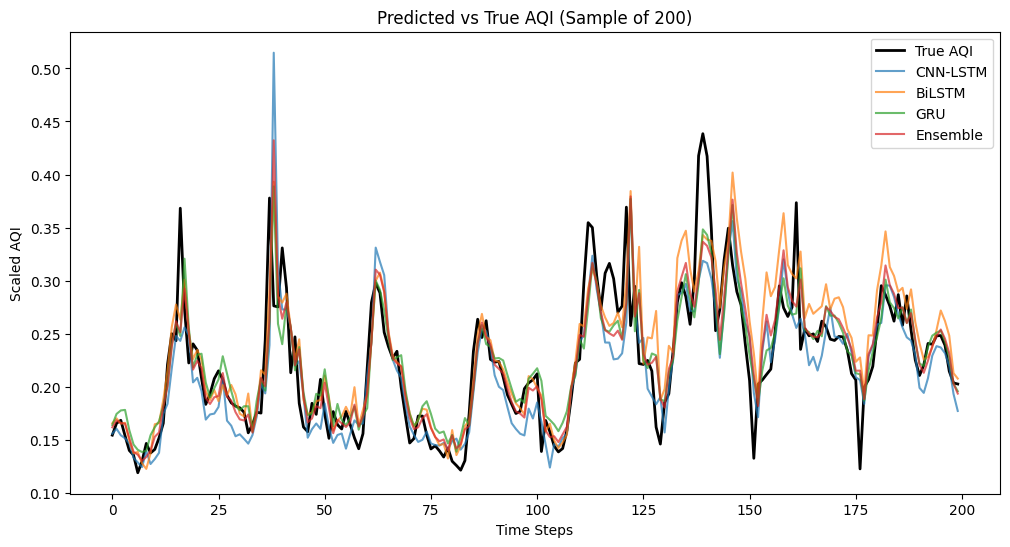

In [14]:
def plot_predictions(y_true, preds, names):
    plt.figure(figsize=(12,6))
    plt.plot(y_true[:200], label='True AQI', color='black', linewidth=2)
    for p, n in zip(preds, names):
        plt.plot(p[:200], label=n, alpha=0.7)
    plt.title('Predicted vs True AQI (Sample of 200)')
    plt.xlabel('Time Steps')
    plt.ylabel('Scaled AQI')
    plt.legend()
    plt.show()

plot_predictions(
    y_test,
    [pred_cnnlstm, pred_bilstm, pred_gru, ensemble_pred],
    ["CNN-LSTM", "BiLSTM", "GRU", "Ensemble"]
)


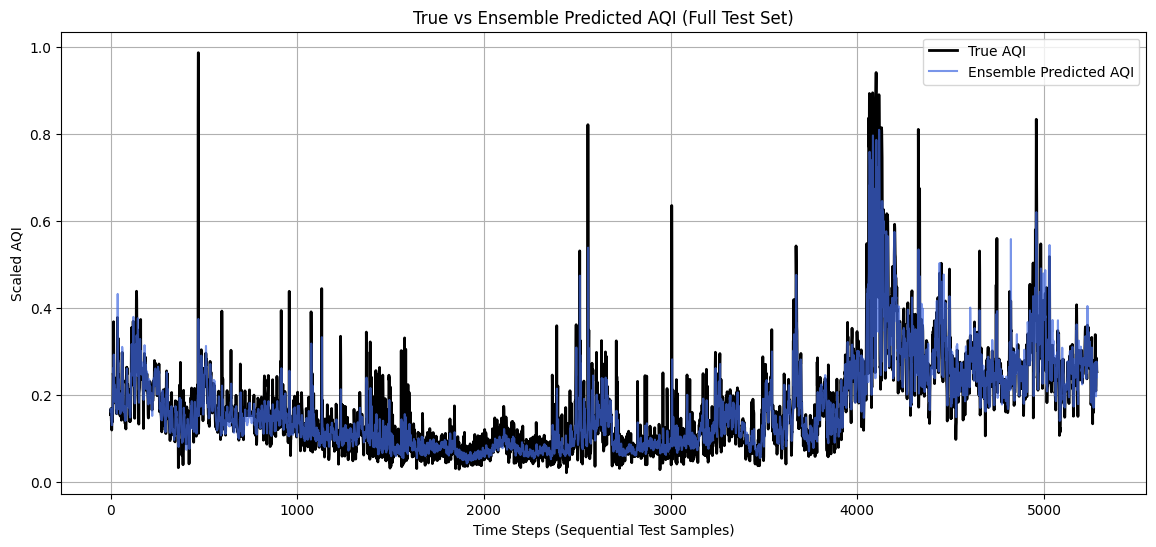

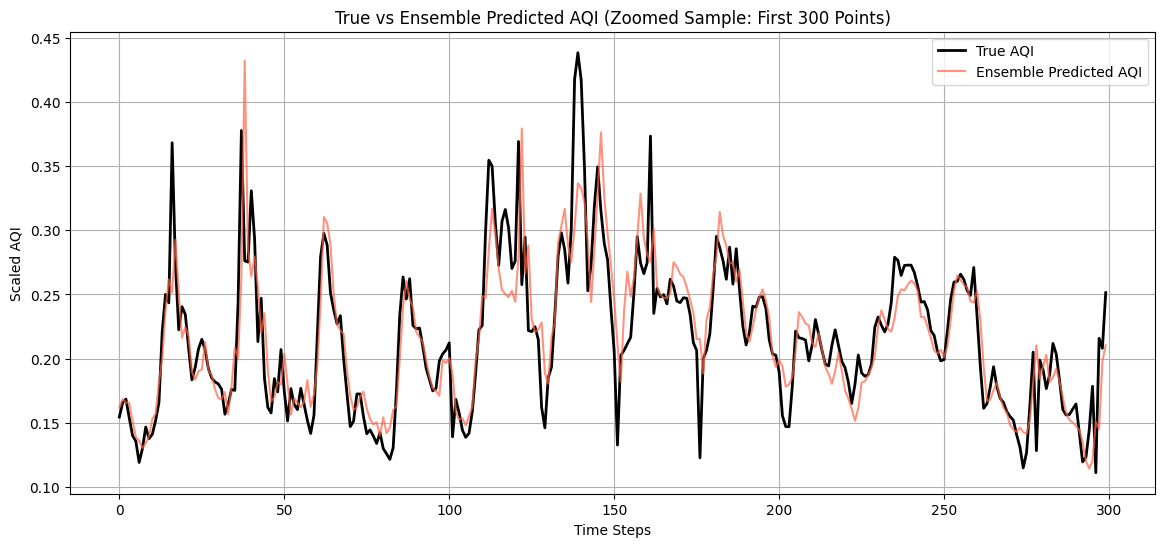

In [15]:
# ---- ENSEMBLE PREDICTION VISUALIZATION ----

import matplotlib.pyplot as plt
import numpy as np

# Plot full test sequence comparison
plt.figure(figsize=(14,6))
plt.plot(y_test, label='True AQI', color='black', linewidth=2)
plt.plot(ensemble_pred, label='Ensemble Predicted AQI', color='royalblue', alpha=0.7)
plt.title('True vs Ensemble Predicted AQI (Full Test Set)')
plt.xlabel('Time Steps (Sequential Test Samples)')
plt.ylabel('Scaled AQI')
plt.legend()
plt.grid(True)
plt.show()

# Plot zoomed sample comparison (first 300 samples)
plt.figure(figsize=(14,6))
plt.plot(y_test[:300], label='True AQI', color='black', linewidth=2)
plt.plot(ensemble_pred[:300], label='Ensemble Predicted AQI', color='tomato', alpha=0.7)
plt.title('True vs Ensemble Predicted AQI (Zoomed Sample: First 300 Points)')
plt.xlabel('Time Steps')
plt.ylabel('Scaled AQI')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split a small tail of training data for calibration
val_split = int(len(X_train)*0.9)
X_val = X_train[val_split:]
y_val = y_train[val_split:]

# Get ensemble preds on that validation slice
p1_val = cnn_lstm_model.predict(X_val, verbose=0).ravel()
p2_val = bilstm_model.predict(X_val, verbose=0).ravel()
p3_val = gru_model.predict(X_val, verbose=0).ravel()
ens_val = np.mean(np.column_stack([p1_val, p2_val, p3_val]), axis=1)

# Fit isotonic regression mapping ensemble→true
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(ens_val, y_val)

# Apply mapping to test ensemble preds
ensemble_cal = iso.transform(ensemble_pred)

# Evaluate
rmse_cal = np.sqrt(mean_squared_error(y_test, ensemble_cal))
r2_cal = r2_score(y_test, ensemble_cal)
print(f"Calibrated Ensemble -> RMSE: {rmse_cal:.3f}, R²: {r2_cal:.3f}")


Calibrated Ensemble -> RMSE: 0.052, R²: 0.799


In [17]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Helper to extract context from last 24-step window
aqi_idx = scaled_df.columns.get_loc("Final_AQI")
wind_idx = scaled_df.columns.get_loc("windspeed_10m")

def end_features(X):
    last_aqi  = X[:, -1, aqi_idx]
    slope_aqi = X[:, -1, aqi_idx] - X[:, -6, aqi_idx]
    vol_aqi   = X[:, -24:, aqi_idx].std(axis=1)
    wind_last = X[:, -1, wind_idx]
    return np.column_stack([last_aqi, slope_aqi, vol_aqi, wind_last])

F_train = end_features(X_train)
F_test  = end_features(X_test)

# Ensemble predictions on training data (for residual model)
p1_tr = cnn_lstm_model.predict(X_train, verbose=0).ravel()
p2_tr = bilstm_model.predict(X_train, verbose=0).ravel()
p3_tr = gru_model.predict(X_train, verbose=0).ravel()
ens_tr = np.mean(np.column_stack([p1_tr, p2_tr, p3_tr]), axis=1)
resid_tr = y_train - ens_tr

# Train residual-corrector on ensemble + context
Z_tr = np.column_stack([ens_tr, F_train])
Z_te = np.column_stack([ensemble_pred, F_test])
res_model = Ridge(alpha=0.5).fit(Z_tr, resid_tr)

# Correct test predictions
ensemble_resfix = ensemble_pred + res_model.predict(Z_te)

rmse_res = np.sqrt(mean_squared_error(y_test, ensemble_resfix))
r2_res = r2_score(y_test, ensemble_resfix)
print(f"Residual-Corrected Ensemble -> RMSE: {rmse_res:.3f}, R²: {r2_res:.3f}")


Residual-Corrected Ensemble -> RMSE: 0.051, R²: 0.799


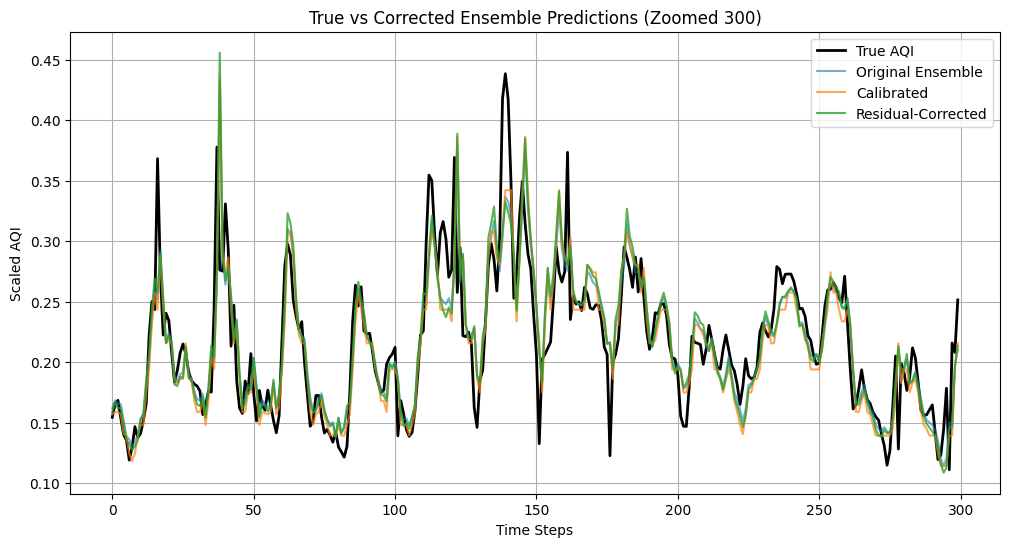

In [18]:
plt.figure(figsize=(12,6))
plt.plot(y_test[:300], label='True AQI', color='black', linewidth=2)
plt.plot(ensemble_pred[:300], label='Original Ensemble', alpha=0.6)
plt.plot(ensemble_cal[:300], label='Calibrated', alpha=0.7)
plt.plot(ensemble_resfix[:300], label='Residual-Corrected', alpha=0.8)
plt.title('True vs Corrected Ensemble Predictions (Zoomed 300)')
plt.xlabel('Time Steps')
plt.ylabel('Scaled AQI')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Re-read just the Datetime to get hours aligned with your sequences
import pandas as pd
dt_full = pd.read_csv("/content/Combined_AQ_Weather_NO2_AQI_2024_Robust.csv")["Datetime"]
hours_full = pd.to_datetime(dt_full).dt.hour.values

TIME_STEPS = 24  # same as you used
def seq_hours(hours_array, time_steps=TIME_STEPS):
    # one hour per sample, at the prediction time (end of each window)
    return hours_array[time_steps:]

H_all = seq_hours(hours_full, TIME_STEPS)

# Same chronological split you used for X/y
split_idx = int(len(H_all) * 0.8)
H_train, H_test = H_all[:split_idx], H_all[split_idx:]

print("H_train/H_test:", H_train.shape, H_test.shape)


H_train/H_test: (21136,) (5285,)


In [20]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# small tail of TRAIN for calibration (no leakage)
val_split = int(len(X_train)*0.90)
X_val, y_val, H_val = X_train[val_split:], y_train[val_split:], H_train[val_split:]

# get ensemble preds on validation slice (use your trained models)
p1_val = cnn_lstm_model.predict(X_val, verbose=0).ravel()
p2_val = bilstm_model.predict(X_val, verbose=0).ravel()
p3_val = gru_model.predict(X_val, verbose=0).ravel()
ens_val = np.mean(np.column_stack([p1_val, p2_val, p3_val]), axis=1)

# train 24 monotonic maps (fallback to global if a bin is too small)
isos = {}
for h in range(24):
    m = (H_val == h)
    if m.sum() >= 40:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(ens_val[m], y_val[m])
        isos[h] = iso

# apply per-hour calibration to TEST
ens_regime_cal = np.empty_like(ensemble_pred)
for h in range(24):
    m = (H_test == h)
    if h in isos:
        ens_regime_cal[m] = isos[h].transform(ensemble_pred[m])
    else:
        ens_regime_cal[m] = ensemble_pred[m]  # fallback

rmse_rc = np.sqrt(mean_squared_error(y_test, ens_regime_cal))
r2_rc   = r2_score(y_test, ens_regime_cal)
print(f"Regime-Calibrated -> RMSE: {rmse_rc:.3f}, R²: {r2_rc:.3f}")


Regime-Calibrated -> RMSE: 0.060, R²: 0.731


In [21]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

aqi_idx  = scaled_df.columns.get_loc("Final_AQI")
wind_idx = scaled_df.columns.get_loc("windspeed_10m")

def end_features(X, H):
    last_aqi  = X[:, -1, aqi_idx]
    slope6    = X[:, -1, aqi_idx] - X[:, -6, aqi_idx]
    vol24     = X[:, -24:, aqi_idx].std(axis=1)
    wind_last = X[:, -1, wind_idx]
    # cyclical hour features
    hour_sin  = np.sin(2*np.pi*H/24)
    hour_cos  = np.cos(2*np.pi*H/24)
    return np.column_stack([last_aqi, slope6, vol24, wind_last, hour_sin, hour_cos])

F_train = end_features(X_train, H_train)
F_test  = end_features(X_test,  H_test)

# ensemble preds on TRAIN (to learn residuals)
p1_tr = cnn_lstm_model.predict(X_train, verbose=0).ravel()
p2_tr = bilstm_model.predict(X_train, verbose=0).ravel()
p3_tr = gru_model.predict(X_train, verbose=0).ravel()
ens_tr = np.mean(np.column_stack([p1_tr, p2_tr, p3_tr]), axis=1)
resid_tr = y_train - ens_tr

# train residual model on [ensemble, context]
Z_tr = np.column_stack([ens_tr, F_train])
Z_te = np.column_stack([ensemble_pred, F_test])

res_model = Ridge(alpha=0.5).fit(Z_tr, resid_tr)
ens_resfix = ensemble_pred + res_model.predict(Z_te)

rmse_res = np.sqrt(mean_squared_error(y_test, ens_resfix))
r2_res   = r2_score(y_test, ens_resfix)
print(f"Residual-Corrected (Ridge) -> RMSE: {rmse_res:.3f}, R²: {r2_res:.3f}")


Residual-Corrected (Ridge) -> RMSE: 0.052, R²: 0.799


In [22]:
# !pip install xgboost
from xgboost import XGBRegressor
meta = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                    random_state=42)
meta.fit(Z_tr, resid_tr)
ens_xgbfix = ensemble_pred + meta.predict(Z_te)

rmse_xgb = np.sqrt(mean_squared_error(y_test, ens_xgbfix))
r2_xgb   = r2_score(y_test, ens_xgbfix)
print(f"Residual-Corrected (XGB) -> RMSE: {rmse_xgb:.3f}, R²: {r2_xgb:.3f}")


Residual-Corrected (XGB) -> RMSE: 0.051, R²: 0.803
